In [56]:
import numpy as np
from numpy.linalg import svd
from PIL import Image
import matplotlib.pyplot as plt

In [124]:
# open image file
img: Image.Image = Image.open("./data/mountain.jpg")

def compress_channel(A: np.ndarray, r: int) -> np.ndarray:
    # SVD
    U, s, Vh = svd(A)
    
    # keep first r singular values
    U = U[:, :r]
    s = s[:r]
    Vh = Vh[:r, :]
    A_hat = (U * s) @ Vh 
    
    # clip pixel values
    A_hat = np.clip(A_hat, a_min = 0, a_max = 255)
    A_hat = A_hat.astype(np.uint8)
    
    return A_hat

def compress_image(img: Image.Image, r: int) -> Image.Image:
    # split RGB channels
    channels: list[Image.Image] = img.split()
    
    compressed_channels = []
    for channel in channels:
        # convert image to NumPy array
        A = np.array(channel)
        
        # compress single channel
        A_hat = compress_channel(A, r)
        
        # convert to Image class instance
        channel = Image.fromarray(A_hat)
        compressed_channels.append(channel)
    
    # merge channels
    compressed_img = Image.merge("RGB", compressed_channels)
    
    return compressed_img

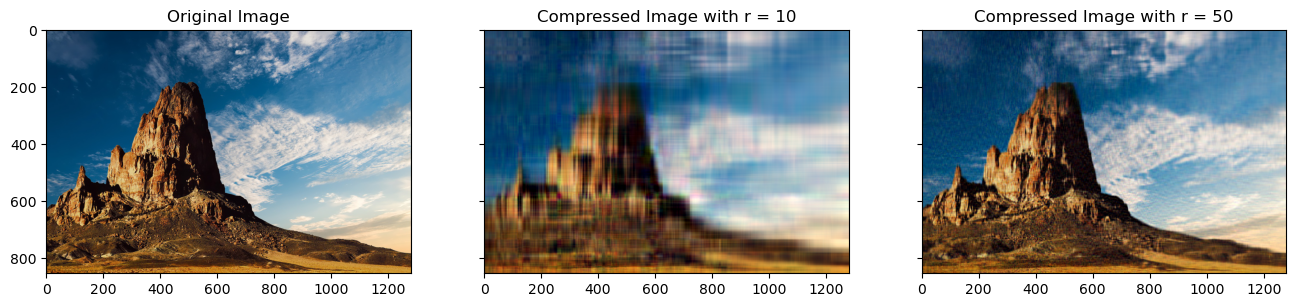

In [131]:
fig, axs = plt.subplots(
    1, 3, 
    figsize = (16, 8),
    sharey = True
)
axs[0].imshow(img)
axs[0].set_title("Original Image")
axs[1].imshow(compress_image(img, r = 10))
axs[1].set_title("Compressed Image with r = 10")
axs[2].imshow(compress_image(img, r = 50))
axs[2].set_title("Compressed Image with r = 50")
    
plt.show()

In [132]:
compress_image(img, r = 10).save("./data/compressed_r10.jpg")
compress_image(img, r = 50).save("./data/compressed_r50.jpg")